## 5. Daten aufbereiten

[Data Science Playlist auf YouTube](https://www.youtube.com/watch?v=tBfGYKITno8&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy)
[![Python Data Science](https://apmonitor.com/che263/uploads/Begin_Python/DataScience05.png)](https://www.youtube.com/watch?v=tBfGYKITno8&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy "Python Data Science")

Ein großer Teil der Arbeit in Data Science und Machine Learning besteht darin, Daten in eine saubere und geeignete Form zu bringen. Dazu können Datenbereinigung zum Entfernen von Ausreißern oder fehlerhaften Einträgen, Skalierung für ML-Algorithmen, das Aufteilen in Trainings- und Testmengen sowie die Umwandlung (Enumeration) von String-Daten gehören. All dies muss vor Regression, Klassifikation oder anderem Modelltraining erfolgen. __Zum Glück__ gibt es Funktionen, die die Datenaufbereitung automatisieren helfen.

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Beispieldaten erzeugen

Führe die folgende Zelle aus, um Beispieldaten zu erzeugen, die mit NaN (not a number) und Ausreißern (fehlerhafte Datenpunkte weit außerhalb des erwarteten Trends) verfälscht sind.

In [9]:
import numpy as np
import pandas as pd
np.random.seed(1)
n = 100
tt = np.linspace(0,n-1,n)
x = np.random.rand(n)+10+np.sqrt(tt)
y = np.random.normal(10,x*0.01,n)
x[1] = np.nan; y[2] = np.nan  # 2 NaN (not a number)
for i in range(3):            # 3 Ausreißer hinzufügen (fehlerhafte Datenpunkte)
    ri = np.random.randint(0,n)
    x[ri] += np.random.rand()*100
data = pd.DataFrame(np.vstack((tt,x,y)).T,\
                    columns=['time','x','y'])
data.head()

,time,x,y
0,0.0,10.417022,10.032880
1,1.0,NaN,9.762991
2,2.0,11.414328,NaN
3,3.0,12.034383,10.099642
4,4.0,12.146756,10.027949


![analyze](https://apmonitor.com/che263/uploads/Begin_Python/analyze.png)

### Daten visualisieren

Die Ausreißer werden in einem Semilog-y-Diagramm dargestellt. Die ``NaN``-Werte erscheinen nicht im Diagramm und fehlen als Punkte.

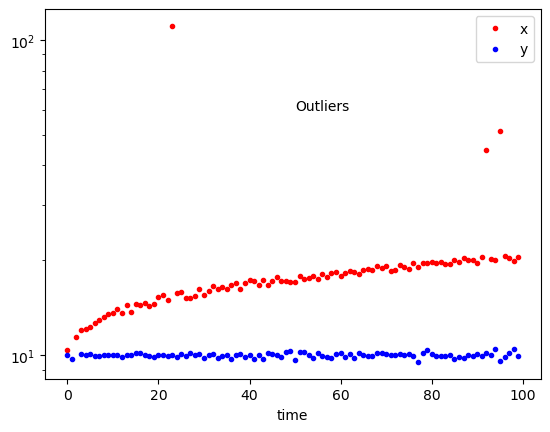

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.semilogy(tt,x,'r.',label='x')
plt.semilogy(tt,y,'b.',label='y')
plt.legend(); plt.xlabel('time')
plt.text(50,60,'Outliers')
plt.show()

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Ausreißer und fehlerhafte Daten entfernen

``NaN``-Werte werden mit ``numpy`` entfernt, indem Zeilen ``iz`` identifiziert werden, die ``NaN`` enthalten. Anschließend werden die Zeilen mit ``z = z[~iz]`` entfernt, wobei ``~`` ein bitweiser ``not``-Operator ist.


In [15]:
z = np.array([[      1,      2],
              [ np.nan,      3],
              [      4, np.nan],
              [      5,      6]])
iz = np.any(np.isnan(z), axis=1)
print(~iz)
z = z[~iz]
print(z)

[ True False False  True]
[[1. 2.]
 [5. 6.]]


``dropna`` ist ein Befehl, um ``NaN``-Zeilen in einem ``pandas-DataFrame`` zu entfernen. Die Zeilen 1 und 2 werden entfernt.

In [18]:
# Entferne jede Zeile mit fehlerhaften (NaN)-Werten
data = data.dropna()
data.head()

,time,x,y
0,0.0,10.417022,10.032880
3,3.0,12.034383,10.099642
4,4.0,12.146756,10.027949
5,5.0,12.328407,10.093944
6,6.0,12.635750,9.971907


Es gibt diverse grafische Techniken, um Ausreißer darzustellen. 
Ein Boxplot oder ein Histogramm zeigt die 3 Ausreißerpunkte. Dies ist ein entscheidender Punkt zur Qualitätsprüfung der Daten!

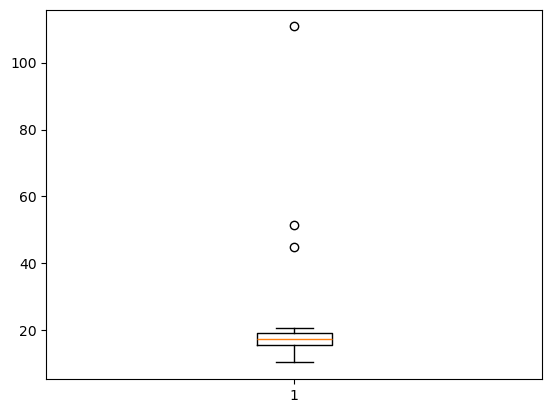

In [21]:
plt.boxplot(data['x'])
plt.show()

Grubbs-Tests oder [andere statistische Verfahren](https://pyod.readthedocs.io/en/latest/) können Ausreißer erkennen. Der Grubbs-Test setzt insbesondere univariate, normalverteilte Daten voraus und ist darauf ausgelegt, nur einen einzelnen Ausreißer zu detektieren. In der Praxis können viele Ausreißer entfernt werden, indem Punkte gelöscht werden, die ein Änderungslimit oder obere/untere Schranken verletzen. Die Anweisung ``data[data['x']<30]`` behält die Zeilen bei, in denen x kleiner als 30 ist.

#### Dies darf nie willkürlich erfolgen - nutzen Sie ihr Prozessverständnis und statistische Tests auf realen Daten
Hier wird die Boxplotmethode verwendet und die Ausreißer mit dieser einfachen Methode automatisch abgebildet.

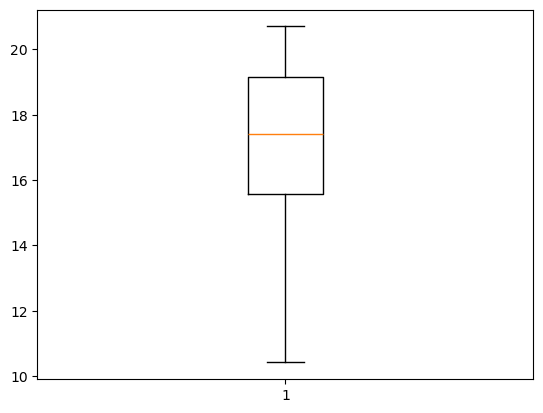

In [32]:
data = data[data['x']<30]
plt.boxplot(data['x'])
plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Zeit-Übung

Führe die folgende Zelle aus, um über 10 Sekunden hinweg Intervalle von 1 Sekunde aufzuzeichnen. 
Drücke nach dem Start der Zelle jedes Mal ``Enter``, wenn du denkst, dass 1 Sekunde vergangen ist. Du darfst dabei keine Uhr verwenden. 
Nutze nach der Datenerfassung ein Boxplot, um Ausreißer in ``tsec`` zu identifizieren.


In [35]:
import time
from IPython.display import clear_output
tsec = []
input('Press "Enter" to record 1 second intervals'); t = time.time()
for i in range(10):
    clear_output(); input('Press "Enter": ' + str(i+1))
    tsec.append(time.time()-t); t = time.time()
clear_output(); print('Completed. Add boxplot to identify outliers')

Completed. Add boxplot to identify outliers


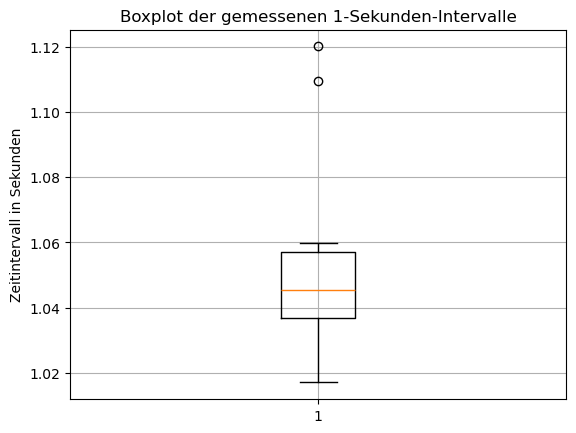

In [37]:
# Add a boxplot to identify outliers
import matplotlib.pyplot as plt

# Boxplot der gemessenen Zeitintervalle erstellen
plt.figure()
plt.boxplot(tsec, vert=True)

# Achsen beschriften
plt.ylabel("Zeitintervall in Sekunden")

# Titel hinzufügen
plt.title("Boxplot der gemessenen 1-Sekunden-Intervalle")

# Gitter anzeigen (optional, aber hilfreich)
plt.grid(True)

# Diagramm anzeigen
plt.show()


![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Daten skalieren

Das Paket ``sklearn`` enthält ein Modul ``preprocessing`` zur Umsetzung gängiger Skalierungsmethoden. Unten ist der ``StandardScaler`` gezeigt, bei dem jede Spalte auf Mittelwert null und Standardabweichung eins normiert wird. Die gebräuchlichen Methoden sind ``fit_transform(X)`` zum Anpassen und Transformieren, ``transform(X)`` zum Transformieren auf Basis eines zuvor erfolgten Fits und ``inverse_transform(Xs)`` zum Zurückskalieren in die ursprüngliche Darstellung.

In [40]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
ds = s.fit_transform(data)
print(ds[0:5]) # gib 5 Zeilen aus

[[-1.78508369 -2.87324163  0.07737234]
 [-1.67768473 -2.1853612   0.50456644]
 [-1.64188508 -2.13756801  0.04582181]
 [-1.60608543 -2.06031011  0.46810748]
 [-1.57028578 -1.9295938  -0.3127774 ]]


Der Wert ``ds`` wird als ``numpy``-Array zurückgegeben; daher müssen wir ihn wieder in ein ``pandas``-``DataFrame`` umwandeln und die Spaltennamen aus ``data`` erneut verwenden.

In [43]:
ds = pd.DataFrame(ds,columns=data.columns)
ds.head()

,time,x,y
0,-1.785084,-2.873242,0.077372
1,-1.677685,-2.185361,0.504566
2,-1.641885,-2.137568,0.045822
3,-1.606085,-2.060310,0.468107
4,-1.570286,-1.929594,-0.312777


![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Daten aufteilen

Die Daten werden in Trainings- und Testmengen aufgeteilt, um einen Teil der Zeilen für die Bewertung von Klassifikations- oder Regressionsmodellen zu reservieren. Ein typischer Split ist 80 % für das Training und 20 % für das Testen, wobei der genaue Anteil von der verfügbaren Datenmenge und dem Ziel der Studie abhängt.

In [46]:
divide = int(len(ds)*0.8)
train = ds[0:divide]
test = ds[divide:]
print(len(train),len(test))

76 19


Die Funktion ``train_test_split`` in ``sklearn`` dient speziell dazu, Daten in Trainings- und Testmengen aufzuteilen. Es gibt Optionen wie ``shuffle=True``, um die Auswahl in jeder Menge zu randomisieren.

In [49]:
from sklearn.model_selection import train_test_split
train,test = train_test_split(ds, test_size=0.2, shuffle=True)
print(len(train),len(test))

76 19


### TCLab-Übung

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Daten mit fehlerhaften Werten und Ausreißern

Erzeuge eine neue Datei mit einigen zufällig eingefügten fehlerhaften Werten (3 Minuten) oder lies die Datei mit dem folgenden Code von [diesem online Link](https://apmonitor.com/do/uploads/Main/tclab_bad_data.txt) ein.

In [52]:
import tclab, time, csv
import numpy as np

try:
    with tclab.TCLab() as lab:
        with open('05-tclab.csv',mode='w',newline='') as f:
            cw = csv.writer(f)
            cw.writerow(['Time','Q1','Q2','T1','T2'])
            print('t Q1 Q2 T1    T2')
            for t in range(180):
                T1 = lab.T1; T2 = lab.T2
                # Füge fehlerhafte Werte ein
                bad = np.random.randint(0,30)
                T1=np.nan if bad==10 else T1
                T2=np.nan if bad==15 else T2
                # Füge eine Zufallszahl ein (möglicher Ausreißer)
                outlier = np.random.randint(-40,150)
                T1=outlier if bad==20 else T1
                T2=outlier if bad==25 else T2
                # Heizstufen ändern
                if t%30==0:
                    Q1 = np.random.randint(0,81)
                    Q2 = np.random.randint(0,81)
                    lab.Q1(Q1); lab.Q2(Q2)
                cw.writerow([t,Q1,Q2,T1,T2])
                if t%10==0:
                    print(t,Q1,Q2,T1,T2)
                time.sleep(1)
            data5=pd.read_csv('05-tclab.csv')
except:
    print('Connect TCLab to generate new data')
    print('Importing data from online source')
    url = 'http://apmonitor.com/do/uploads/Main/tclab_bad_data.txt'
    data5=pd.read_csv(url)

TCLab version 1.0.0
Arduino Leonardo connected on port COM7 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
t Q1 Q2 T1    T2
0 52 57 22.188 2
10 52 57 22.22 21.64
20 52 57 22.961 21.93
30 48 5 24.121 22.961
40 48 5 25.571 23.573
50 48 5 27.054 24.25
60 51 30 28.601 24.766
70 51 30 30.276 25.41
80 51 30 31.855 26.151
90 71 14 33.435 26.764
100 71 14 36 27.344
110 71 14 36.593 27.892
120 38 28 38.301 28.729
130 38 28 40.041 29.406
140 38 28 41.33 29.89
150 30 57 42.329 30.76
160 30 57 42.941 31.598
170 30 57 43.489 32.436
TCLab disconnected successfully.
Connect TCLab to generate new data
Importing data from online source


### Daten bereinigen, skalieren und aufteilen in einem Block

Entferne nach dem Erzeugen und Importieren von ``data5`` alle Zeilen mit ``NaN``-Werten oder Ausreißern in den Spalten ``T1`` oder ``T2``. 
Skaliere die Daten mit einem ``StandardScaler`` in ``scikit``. Teile die Daten in Trainings- (80 %) und Testmenge (20 %) auf.

In [56]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Sicherheitskopie des Original-DataFrames
df = data5.copy()

# -----------------------------
# 1. NaN-Werte entfernen
# -----------------------------
df = df.dropna(subset=["T1", "T2"])

# -----------------------------
# 2. Ausreißer entfernen (IQR-Methode)
# -----------------------------
def entferne_ausreisser(df, spalte):
    Q1 = df[spalte].quantile(0.25)
    Q3 = df[spalte].quantile(0.75)
    IQR = Q3 - Q1
    untere_grenze = Q1 - 1.5 * IQR
    obere_grenze = Q3 + 1.5 * IQR
    return df[(df[spalte] >= untere_grenze) & (df[spalte] <= obere_grenze)]

# Ausreißer in T1 und T2 entfernen
df = entferne_ausreisser(df, "T1")
df = entferne_ausreisser(df, "T2")

# -----------------------------
# 3. Features auswählen und skalieren
# -----------------------------
features = ["Q1", "Q2", "T1", "T2"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# In DataFrame zurückwandeln (optional, aber übersichtlich)
X_scaled = pd.DataFrame(X_scaled, columns=features)

# -----------------------------
# 4. Trainings- und Testdaten aufteilen
# -----------------------------
X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

# Kontrolle ausgeben
print("Anzahl Trainingsdaten:", X_train.shape[0])
print("Anzahl Testdaten:", X_test.shape[0])


Anzahl Trainingsdaten: 128
Anzahl Testdaten: 33
